Phase_2 10 EDA charts 

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [10]:
import pandas as pd

# Load all cleaned CSVs
customers   = pd.read_csv("Cleaned data/customer.csv")
inventory   = pd.read_csv("Cleaned data/inventory.csv")
orders      = pd.read_csv("Cleaned data/orders.csv")
products    = pd.read_csv("Cleaned data/products.csv")
order_items = pd.read_csv("Cleaned data/order_items.csv")
payment     = pd.read_csv("Cleaned data/payment.csv")
returns     = pd.read_csv("Cleaned data/returns.csv")
supplier    = pd.read_csv("Cleaned data/supplier.csv")


In [12]:
# Convert date columns to datetime
orders['order_date']   = pd.to_datetime(orders['order_date'], errors='coerce')
payment['payment_time'] = pd.to_datetime(payment['payment_time'], errors='coerce')
returns['return_date']  = pd.to_datetime(returns['return_date'], errors='coerce')

# Quick check
print("Orders dtype:", orders['order_date'].dtype)
print(orders['order_date'].head())


Orders dtype: datetime64[us]
0   2025-05-22
1   2023-10-16
2   2023-10-08
3   2023-10-02
4   2024-06-15
Name: order_date, dtype: datetime64[us]


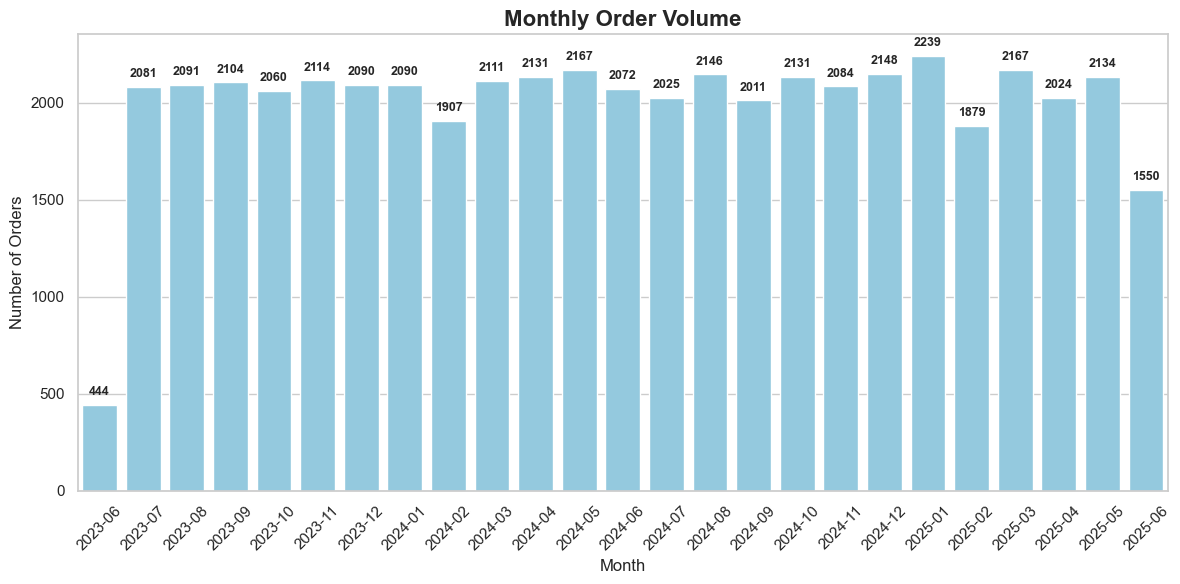

In [15]:
sns.set_theme(style="whitegrid", palette="muted")

# 1. Monthly Order Volume
monthly_orders = orders.groupby(orders['order_date'].dt.to_period('M'))['order_id'].count()
plt.figure(figsize=(12,6))
ax = sns.barplot(x=monthly_orders.index.astype(str), y=monthly_orders.values, color="skyblue")
plt.title("Monthly Order Volume", fontsize=16, fontweight="bold")
plt.xlabel("Month"); plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
for i, v in enumerate(monthly_orders.values):
    ax.text(i, v+50, str(v), ha='center', fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("EDA charts/monthly_order_volume.png", dpi=300)
plt.show()

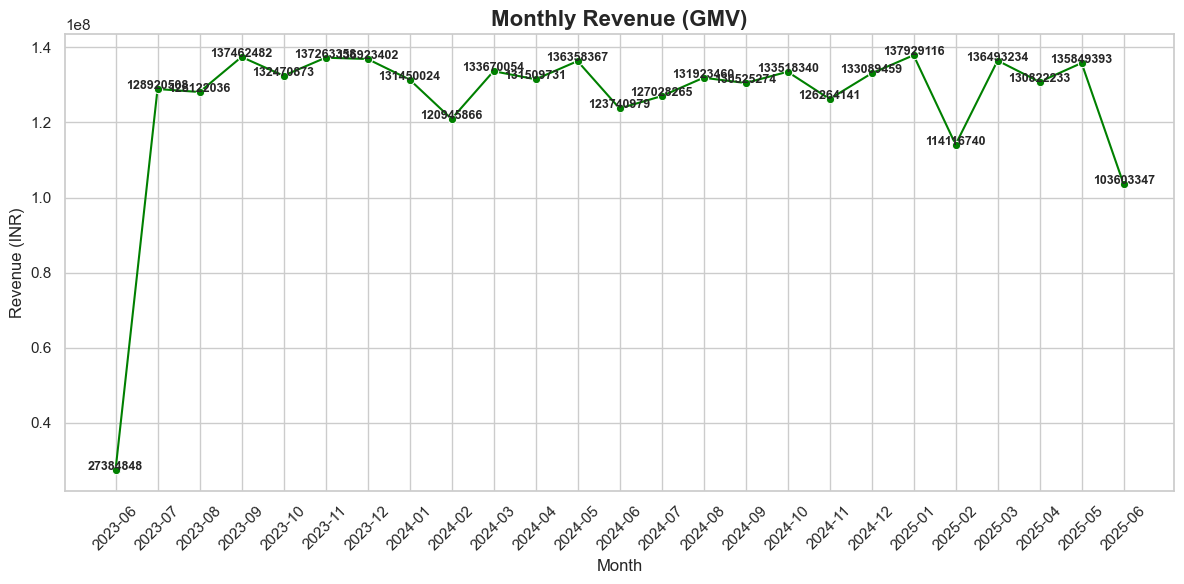

In [16]:
# 2. Monthly Revenue (GMV)
monthly_revenue = orders.groupby(orders['order_date'].dt.to_period('M'))['final_amount'].sum()
plt.figure(figsize=(12,6))
ax = sns.lineplot(x=monthly_revenue.index.astype(str), y=monthly_revenue.values, marker="o", color="green")
plt.title("Monthly Revenue (GMV)", fontsize=16, fontweight="bold")
plt.xlabel("Month"); plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
for i, v in enumerate(monthly_revenue.values):
    plt.text(i, v+1000, str(int(v)), ha='center', fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("EDA charts/monthly_revenue.png", dpi=300)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13996\3585267082.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=category_revenue.values, y=category_revenue.index, palette="coolwarm")


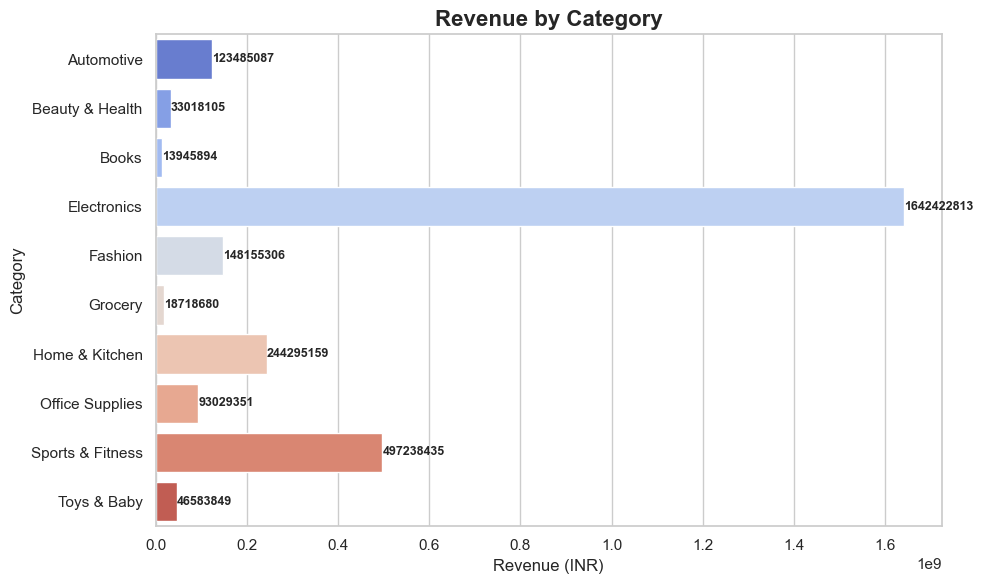

In [17]:
# 3. Category-wise Revenue Share
category_revenue = order_items.groupby('category')['total_price'].sum()
plt.figure(figsize=(10,6))
ax = sns.barplot(x=category_revenue.values, y=category_revenue.index, palette="coolwarm")
plt.title("Revenue by Category", fontsize=16, fontweight="bold")
plt.xlabel("Revenue (INR)"); plt.ylabel("Category")
for i, v in enumerate(category_revenue.values):
    ax.text(v+1000, i, str(int(v)), va='center', fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("EDA charts/category_revenue_share.png", dpi=300)
plt.show()

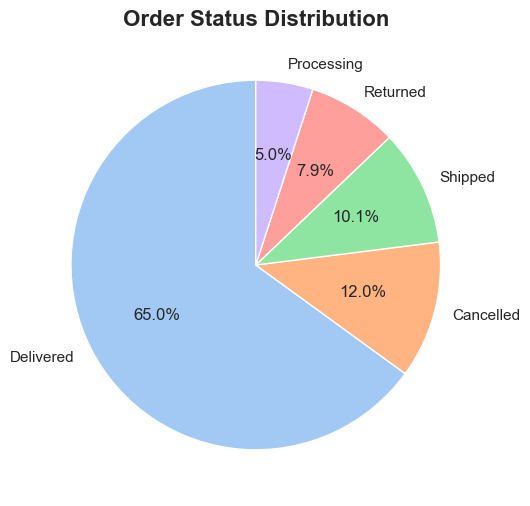

In [18]:
# 4. Order Status Distribution
status_counts = orders['status'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Order Status Distribution", fontsize=16, fontweight="bold")
plt.savefig("EDA charts/order_status_distribution.png", dpi=300)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13996\1033327200.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_states.values, y=top_states.index, palette="Purples_r")


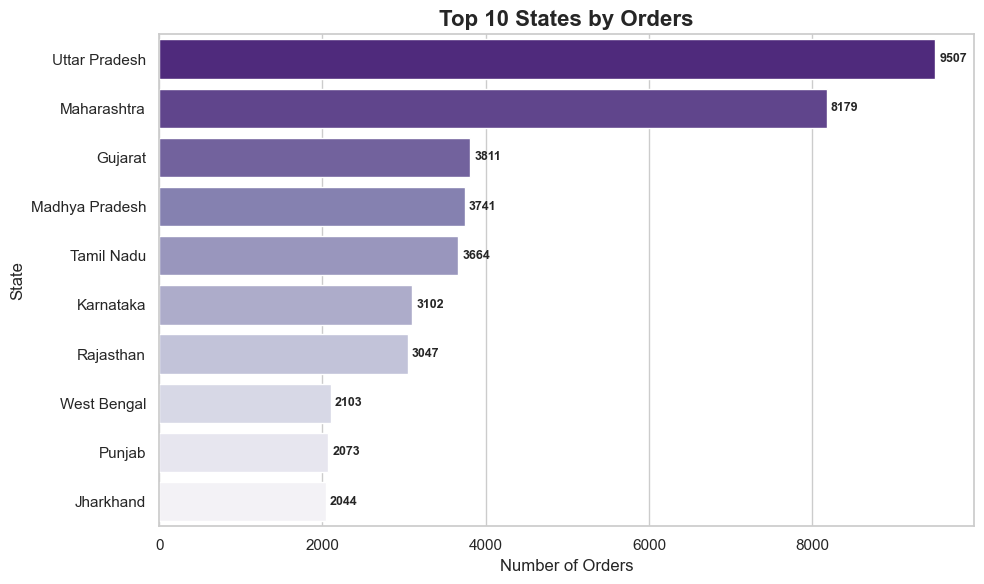

In [19]:
# 5. Top 10 States by Orders
top_states = orders['state'].value_counts().head(10)
plt.figure(figsize=(10,6))
ax = sns.barplot(x=top_states.values, y=top_states.index, palette="Purples_r")
plt.title("Top 10 States by Orders", fontsize=16, fontweight="bold")
plt.xlabel("Number of Orders"); plt.ylabel("State")
for i, v in enumerate(top_states.values):
    ax.text(v+50, i, str(v), va='center', fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("EDA charts/top_states_orders.png", dpi=300)
plt.show()

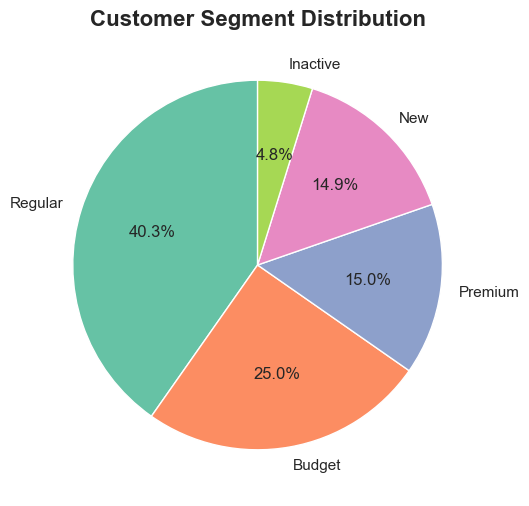

In [20]:
# 6. Customer Segment Distribution
segment_counts = customers['segment'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2"))
plt.title("Customer Segment Distribution", fontsize=16, fontweight="bold")
plt.savefig("EDA charts/customer_segment_distribution.png", dpi=300)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13996\4284956693.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=payment_methods.index, y=payment_methods.values, palette="Blues")


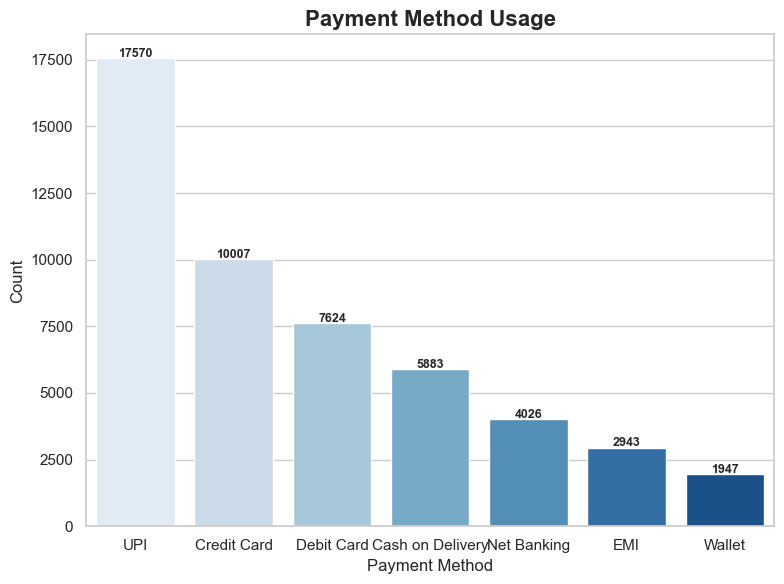

In [21]:
# 7. Payment Method Usage
payment_methods = orders['payment_method'].value_counts()
plt.figure(figsize=(8,6))
ax = sns.barplot(x=payment_methods.index, y=payment_methods.values, palette="Blues")
plt.title("Payment Method Usage", fontsize=16, fontweight="bold")
plt.xlabel("Payment Method"); plt.ylabel("Count")
for i, v in enumerate(payment_methods.values):
    ax.text(i, v+50, str(v), ha='center', fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("EDA charts/payment_method_usage.png", dpi=300)
plt.show()

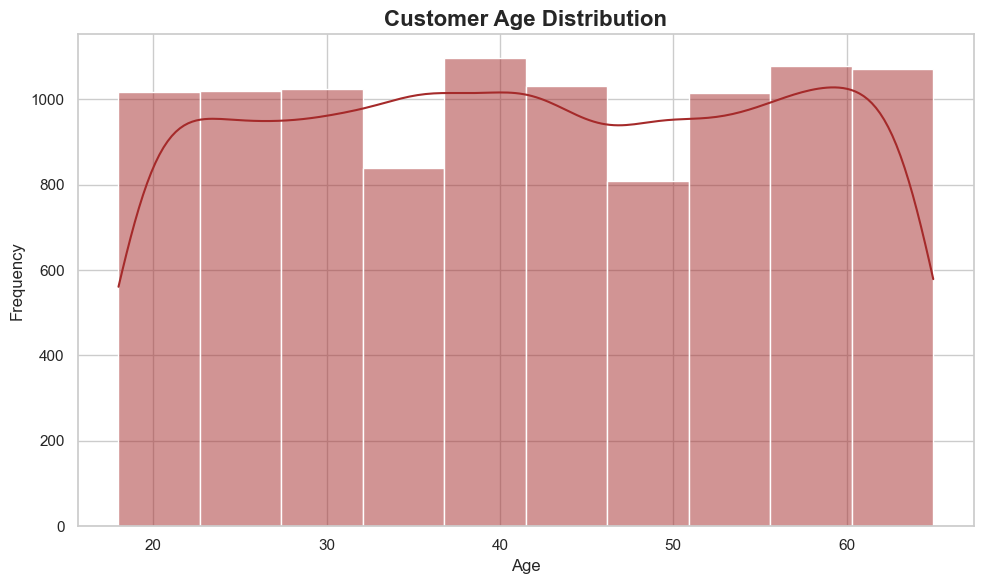

In [22]:
# 8. Age Distribution of Customers
plt.figure(figsize=(10,6))
sns.histplot(customers['age'], bins=10, color="brown", kde=True)
plt.title("Customer Age Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Age"); plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("EDA charts/customer_age_distribution.png", dpi=300)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13996\1034648166.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=return_reasons.values, y=return_reasons.index, palette="Reds")


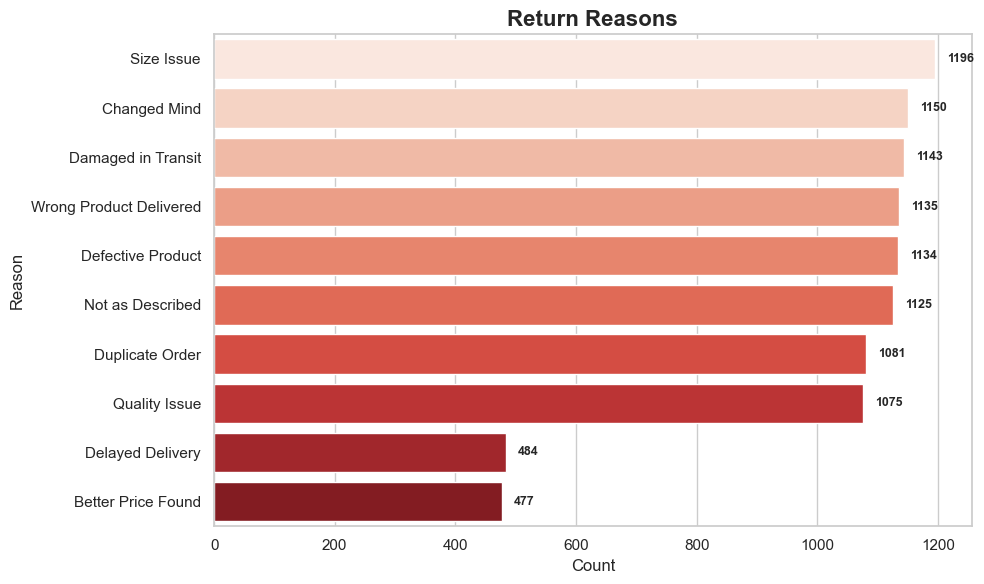

In [23]:
# 9. Return Reasons
return_reasons = returns['reason'].value_counts()
plt.figure(figsize=(10,6))
ax = sns.barplot(x=return_reasons.values, y=return_reasons.index, palette="Reds")
plt.title("Return Reasons", fontsize=16, fontweight="bold")
plt.xlabel("Count"); plt.ylabel("Reason")
for i, v in enumerate(return_reasons.values):
    ax.text(v+20, i, str(v), va='center', fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("EDA charts/return_reasons.png", dpi=300)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13996\1915918667.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=aov_segment_group.index, y=aov_segment_group.values, palette="Greens")


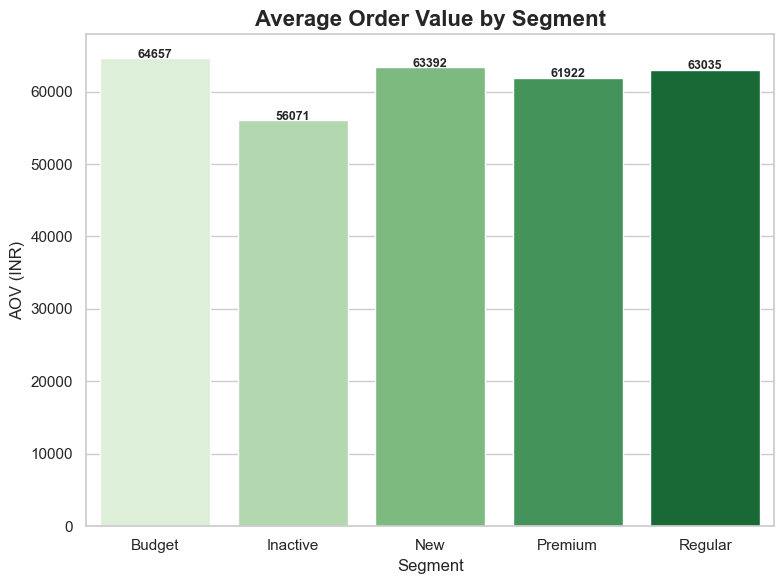

In [25]:
# 10. Average Order Value (AOV) by Segment
aov_segment = orders.groupby('customer_id')['final_amount'].mean().reset_index()
aov_segment = aov_segment.merge(customers[['customer_id','segment']], on='customer_id')
aov_segment_group = aov_segment.groupby('segment')['final_amount'].mean()
plt.figure(figsize=(8,6))
ax = sns.barplot(x=aov_segment_group.index, y=aov_segment_group.values, palette="Greens")
plt.title("Average Order Value by Segment", fontsize=16, fontweight="bold")
plt.xlabel("Segment"); plt.ylabel("AOV (INR)")
for i, v in enumerate(aov_segment_group.values):
    ax.text(i, v+50, str(int(v)), ha='center', fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("EDA charts/aov_by_segment.png", dpi=300)
plt.show()

Bonus Charts

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13996\224751257.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=revenue_by_day.index, y=revenue_by_day.values, palette="Spectral")


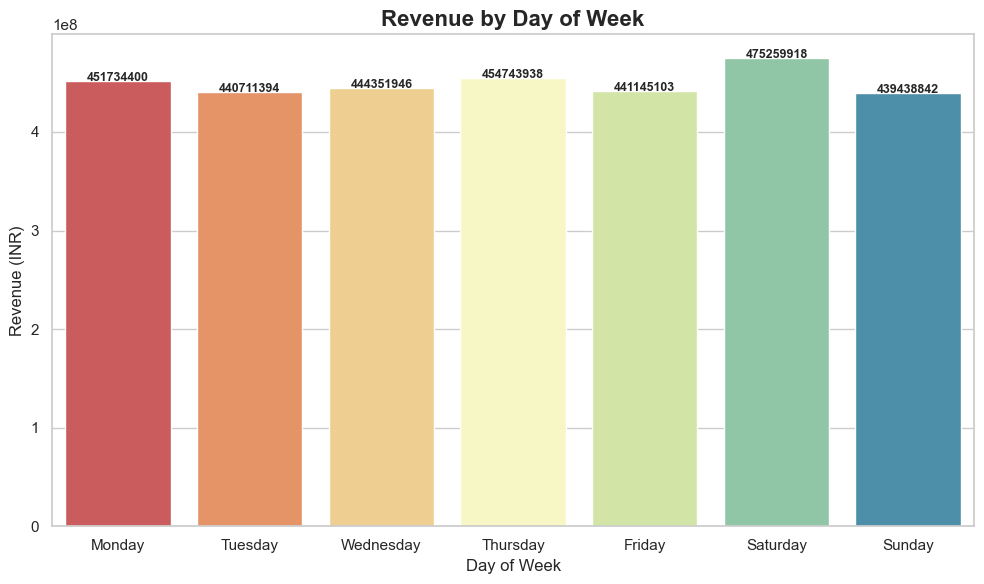

In [28]:
#Revenue by Day of Week
orders['day_of_week'] = orders['order_date'].dt.day_name()
revenue_by_day = orders.groupby('day_of_week')['final_amount'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

plt.figure(figsize=(10,6))
ax = sns.barplot(x=revenue_by_day.index, y=revenue_by_day.values, palette="Spectral")
plt.title("Revenue by Day of Week", fontsize=16, fontweight="bold")
plt.xlabel("Day of Week"); plt.ylabel("Revenue (INR)")
for i, v in enumerate(revenue_by_day.values):
    ax.text(i, v+1000, str(int(v)), ha='center', fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("EDA charts/revenue_by_day.png", dpi=300)
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13996\3522610045.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


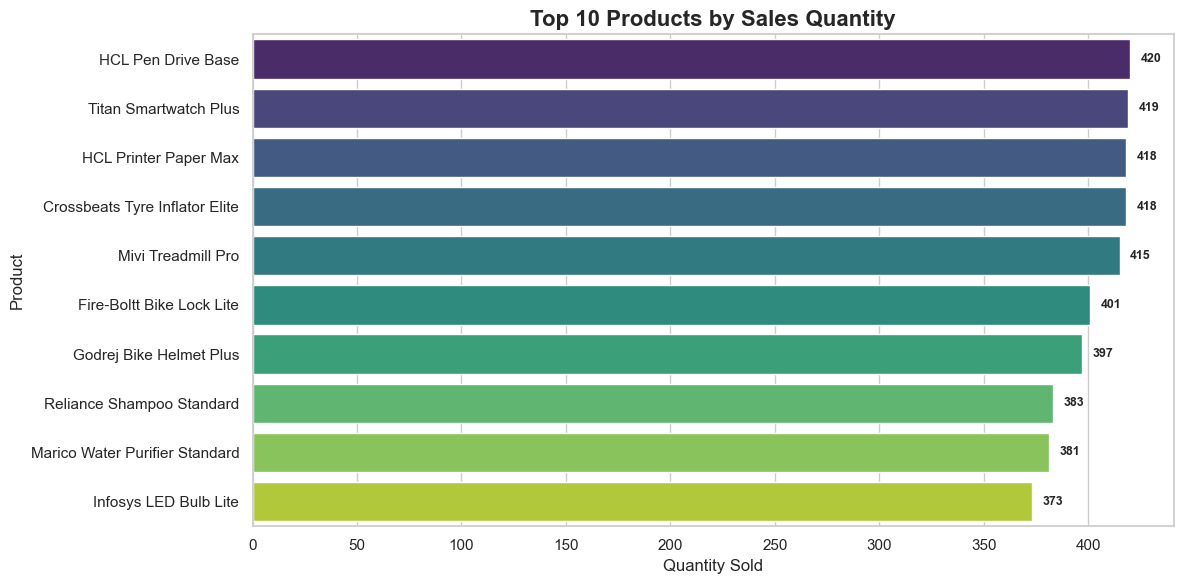

In [29]:
#Top 10 Products by Sales Quantity
top_products = order_items.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
ax = sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.title("Top 10 Products by Sales Quantity", fontsize=16, fontweight="bold")
plt.xlabel("Quantity Sold"); plt.ylabel("Product")
for i, v in enumerate(top_products.values):
    ax.text(v+5, i, str(v), va='center', fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("EDA charts/top_products_sales.png", dpi=300)
plt.show()


In [30]:
#save all files in Cleaned data folder
customers.to_csv("Cleaned data/customer.csv",index=False)
inventory.to_csv("Cleaned data/inventory.csv",index=False)
orders.to_csv("Cleaned data/orders.csv",index=False)
products.to_csv("Cleaned data/products.csv",index=False)
order_items.to_csv("Cleaned data/order_items.csv",index=False)
payment.to_csv("Cleaned data/payment.csv",index=False)
returns.to_csv("Cleaned data/returns.csv",index=False)
supplier.to_csv("Cleaned data/supplier.csv",index=False)